<a href="https://colab.research.google.com/github/fdegolla/MAT-422-Francisco-Degollado/blob/main/MAT422_HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Homework 1.3

**Name:** Francisco Degollado

## Topics
- 1.3.1 QR Decomposition
- 1.3.2 Least-Squares Problems
- 1.3.3 Linear Regression

In [1]:
import numpy as np

## 1.3.1 QR Decomposition

QR decomposition factors a matrix $A$ into two matrices:

$$
A = QR
$$

where $Q$ has orthonormal columns and $R$ is an upper triangular matrix.

Consider the matrix:

$$
A =
\begin{bmatrix}
1 & 1\\
1 & -1\\
1 & 0
\end{bmatrix}
$$

We can use Python to find the QR decomposition and verify that multiplying $Q$ and $R$ gives the original matrix $A$.

In [2]:
# Define the matrix A
A = np.array([
    [1.0, 1.0],
    [1.0, -1.0],
    [1.0, 0.0]
])

# Calculate the QR decomposition
Q, R = np.linalg.qr(A)

print("Matrix Q:")
print(Q)

print("\nMatrix R:")
print(R)

Matrix Q:
[[-0.57735027  0.70710678]
 [-0.57735027 -0.70710678]
 [-0.57735027  0.        ]]

Matrix R:
[[-1.73205081  0.        ]
 [ 0.          1.41421356]]


In [3]:
# Verify that Q has orthonormal columns
print("Q^T Q:")
print(np.round(Q.T @ Q, 10))

# Verify that QR equals A
reconstructed_A = Q @ R

print("\nQ @ R:")
print(np.round(reconstructed_A, 10))

print("\nQR equals A:", np.allclose(reconstructed_A, A))

Q^T Q:
[[ 1. -0.]
 [-0.  1.]]

Q @ R:
[[ 1.  1.]
 [ 1. -1.]
 [ 1.  0.]]

QR equals A: True


### Interpretation

The QR decomposition produced the matrices $Q$ and $R$. The result $Q^TQ = I$ verifies that the columns of $Q$ are orthonormal. Multiplying $Q$ and $R$ reconstructs the original matrix $A$, and the verification returns `True`. Therefore, the QR decomposition satisfies $A = QR$.

## 1.3.2 Least-Squares Problems

A least-squares problem is used when a system $Ax=b$ does not have an exact solution. The goal is to find an approximate solution $\hat{x}$ that minimizes the error between $A\hat{x}$ and $b$.

Consider the system:

$$
A =
\begin{bmatrix}
1 & 1\\
1 & 2\\
1 & 3
\end{bmatrix},
\qquad
b =
\begin{bmatrix}
1\\
2\\
2
\end{bmatrix}
$$

We can use Python to find the least-squares solution and examine the difference between the predicted values $A\hat{x}$ and the actual values $b$.

In [4]:
# Define A and b
A = np.array([
    [1.0, 1.0],
    [1.0, 2.0],
    [1.0, 3.0]
])

b = np.array([1.0, 2.0, 2.0])

# Calculate the least-squares solution
x_hat, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

print("Least-squares solution:")
print(x_hat)

print("\nResidual sum of squares:")
print(residuals)

Least-squares solution:
[0.66666667 0.5       ]

Residual sum of squares:
[0.16666667]


In [5]:
# Calculate the predicted values
predicted_b = A @ x_hat

# Calculate the residual vector
residual = b - predicted_b

print("Actual b:")
print(b)

print("\nPredicted A*x_hat:")
print(np.round(predicted_b, 4))

print("\nResidual b - A*x_hat:")
print(np.round(residual, 4))

Actual b:
[1. 2. 2.]

Predicted A*x_hat:
[1.1667 1.6667 2.1667]

Residual b - A*x_hat:
[-0.1667  0.3333 -0.1667]


### Interpretation

The system does not have an exact solution, so the least-squares method finds the best approximate solution. Python gives $\hat{x} \approx (0.667, 0.5)$. The predicted values are close to the actual values, and the residual vector shows the remaining error between $A\hat{x}$ and $b$.

## 1.3.3 Linear Regression

Linear regression finds a line that best represents the relationship between two variables. The regression line has the form:

$$
y = mx + b
$$

where $m$ is the slope and $b$ is the y-intercept.

Consider the data points:

$$
(1,2),\ (2,3),\ (3,5),\ (4,4),\ (5,6)
$$

We can use Python to find the least-squares regression line and compare the fitted line with the original data.

In [6]:
# Define the data points
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.0, 3.0, 5.0, 4.0, 6.0])

# Calculate the linear regression line
m, b = np.polyfit(x, y, 1)

print("Slope =", m)
print("Y-intercept =", b)

print("\nRegression equation:")
print("y =", round(m, 4), "x +", round(b, 4))

Slope = 0.8999999999999998
Y-intercept = 1.3000000000000012

Regression equation:
y = 0.9 x + 1.3


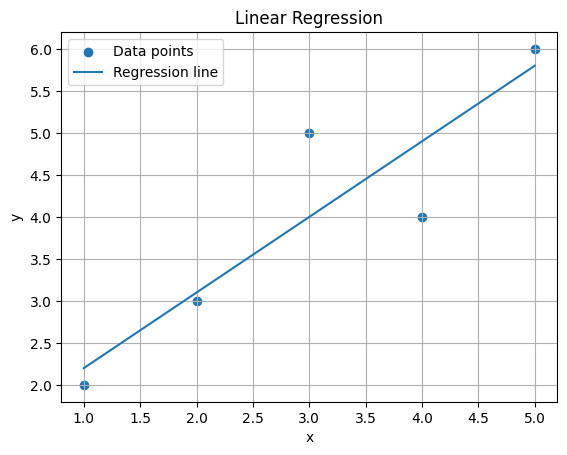

In [7]:
import matplotlib.pyplot as plt

# Calculate predicted y-values
y_predicted = m * x + b

# Plot the original data points
plt.scatter(x, y, label="Data points")

# Plot the regression line
plt.plot(x, y_predicted, label="Regression line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.grid()

plt.show()

### Interpretation

The least-squares regression line is approximately $y = 0.9x + 1.3$. The positive slope shows that $y$ generally increases as $x$ increases. The graph shows that the regression line follows the overall trend of the data even though it does not pass through every data point.